In [1]:
# IMPORT LIBRARIES
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV,GridSearchCV

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from imblearn.over_sampling import SMOTE


In [2]:
# LOAD DATA
df = pd.read_csv(r"C:\Users\waniu\Desktop\2026\2026\instafakeprofile.csv")
print(df.head(5))
print(df.tail(5))

   edge_followed_by  edge_follow  username_length  username_has_number  \
0             0.001        0.257               13                    1   
1             0.000        0.958                9                    1   
2             0.000        0.253               12                    0   
3             0.000        0.977               10                    1   
4             0.000        0.321               11                    0   

   full_name_has_number  full_name_length  is_private  is_joined_recently  \
0                     1                13           0                   0   
1                     0                 0           0                   1   
2                     0                 0           0                   0   
3                     0                 0           0                   0   
4                     0                11           1                   0   

   has_channel  is_business_account  has_guides  has_external_url  is_fake  
0            0 

In [3]:
#checking the shape and info of the dataset
print(df.shape)
print(df.info())

(785, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785 entries, 0 to 784
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   edge_followed_by      785 non-null    float64
 1   edge_follow           785 non-null    float64
 2   username_length       785 non-null    int64  
 3   username_has_number   785 non-null    int64  
 4   full_name_has_number  785 non-null    int64  
 5   full_name_length      785 non-null    int64  
 6   is_private            785 non-null    int64  
 7   is_joined_recently    785 non-null    int64  
 8   has_channel           785 non-null    int64  
 9   is_business_account   785 non-null    int64  
 10  has_guides            785 non-null    int64  
 11  has_external_url      785 non-null    int64  
 12  is_fake               785 non-null    int64  
dtypes: float64(2), int64(11)
memory usage: 79.9 KB
None


In [4]:
# #checking the null values
print(df.isnull().sum())

# Check duplicate rows
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)


edge_followed_by        0
edge_follow             0
username_length         0
username_has_number     0
full_name_has_number    0
full_name_length        0
is_private              0
is_joined_recently      0
has_channel             0
is_business_account     0
has_guides              0
has_external_url        0
is_fake                 0
dtype: int64
Number of duplicate rows: 3


In [5]:
print("Class Distribution:\n", df["is_fake"].value_counts())

Class Distribution:
 is_fake
1    692
0     93
Name: count, dtype: int64


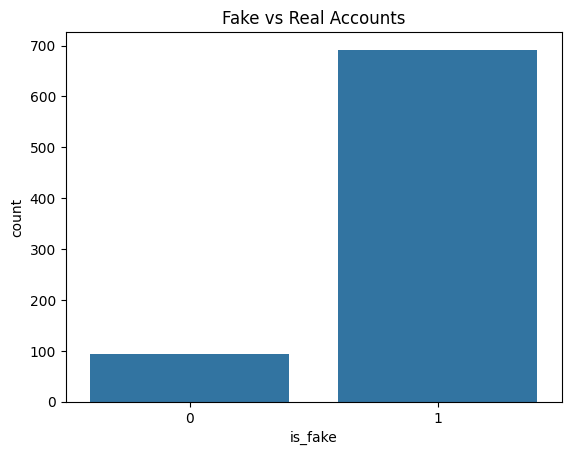

In [7]:
sns.countplot(x='is_fake', data=df)
plt.title("Fake vs Real Accounts")
plt.show()

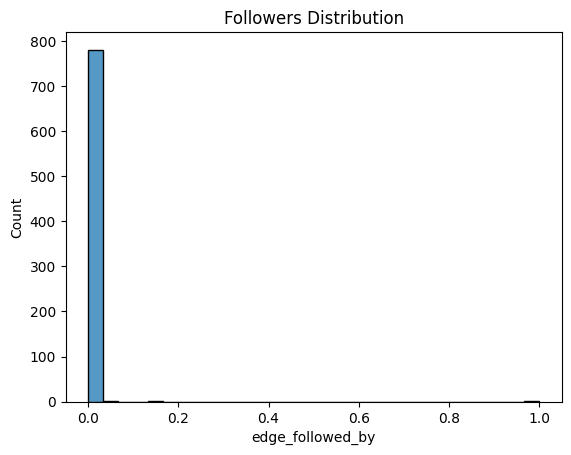

In [8]:
sns.histplot(df['edge_followed_by'], bins=30)
plt.title("Followers Distribution")
plt.show()

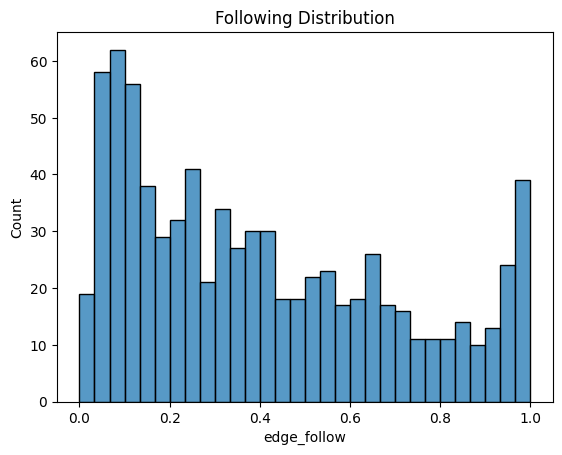

In [9]:
sns.histplot(df['edge_follow'], bins=30)
plt.title("Following Distribution")
plt.show()

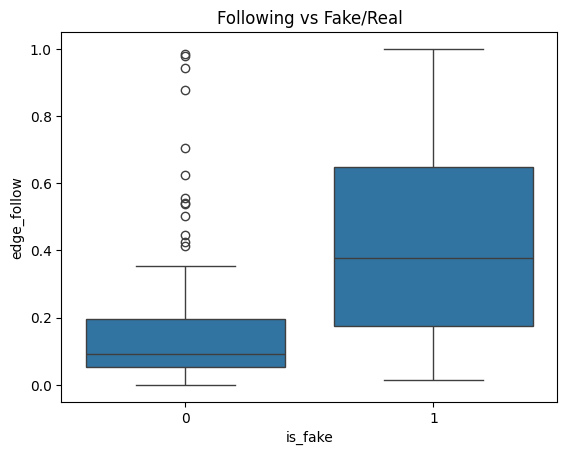

In [10]:
sns.boxplot(x='is_fake', y='edge_follow', data=df)
plt.title("Following vs Fake/Real")
plt.show()

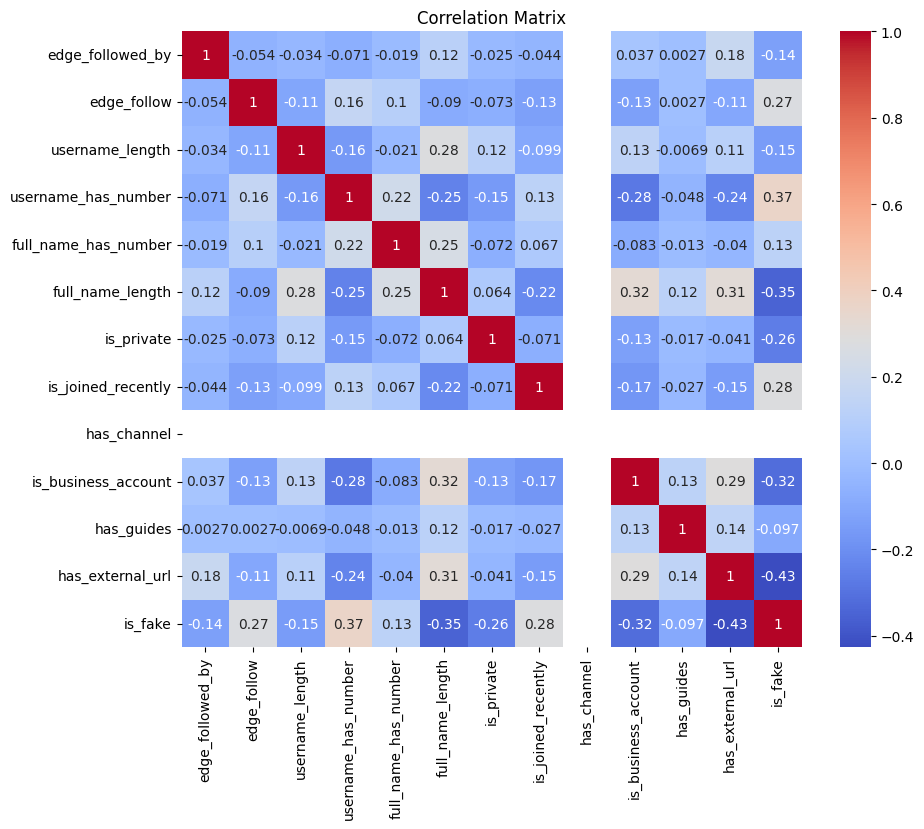

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [12]:
# FEATURES & TARGET
x = df.drop("is_fake", axis=1)
y = df["is_fake"]


In [14]:
#  TRAIN-TEST SPLIT
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

In [15]:
# SMOTE
sm = SMOTE( random_state=42)
x_train_sm, y_train_sm = sm.fit_resample(x_train, y_train)



In [16]:
#SCALING
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train_sm)
x_test_scaled = scaler.transform(x_test)


In [17]:
# EVALUATION FUNCTION

def evaluate_model(name, model, x_train, y_train, x_test, y_test):

    train_pred = model.predict(x_train)
    test_pred = model.predict(x_test)

    print(f"\n {name} ")
    print(f"Train Accuracy : {accuracy_score(y_train, train_pred):.4f}")
    print(f"Test Accuracy  : {accuracy_score(y_test, test_pred):.4f}")

    print("\nTest Metrics ")
    print("Precision:", precision_score(y_test, test_pred, zero_division=0))
    print("Recall   :", recall_score(y_test, test_pred, zero_division=0))
    print("F1 Score :", f1_score(y_test, test_pred, zero_division=0))

    cm = confusion_matrix(y_test, test_pred)

    print("\nConfusion Matrix:")
    print(cm)

    print("\nClassification Report:")
    print(classification_report(y_test, test_pred, zero_division=0))

    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d',
    xticklabels=['Real','Fake'],
    yticklabels=['Real','Fake'])
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    

    



Best LR Params: {'C': 0.1, 'solver': 'liblinear'}

 Logistic Regression 
Train Accuracy : 0.8908
Test Accuracy  : 0.8981

Test Metrics 
Precision: 0.9841269841269841
Recall   : 0.8985507246376812
F1 Score : 0.9393939393939394

Confusion Matrix:
[[ 17   2]
 [ 14 124]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.89      0.68        19
           1       0.98      0.90      0.94       138

    accuracy                           0.90       157
   macro avg       0.77      0.90      0.81       157
weighted avg       0.93      0.90      0.91       157



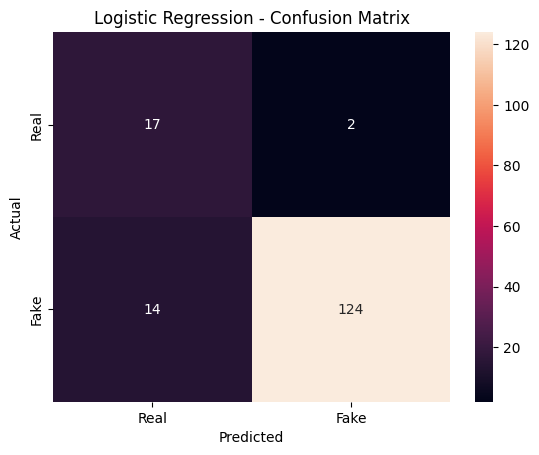

In [18]:
#  LOGISTIC REGRESSION 
param_lr = {
    'C': [0.01, 0.05, 0.1, 0.5, 1],  
    'solver': ['lbfgs', 'liblinear'],
    
}

gs_lr =GridSearchCV(
    LogisticRegression(),
    param_lr,
    cv=5,
    scoring='f1'
)

gs_lr.fit(x_train_scaled, y_train_sm)
print("Best LR Params:", gs_lr.best_params_)

best_lr = gs_lr.best_estimator_
evaluate_model("Logistic Regression", best_lr, x_train_scaled, y_train_sm, x_test_scaled, y_test)

Best SVM Params: {'C': 1, 'gamma': 0.1, 'kernel': 'rbf'}

 SVM 
Train Accuracy : 0.9233
Test Accuracy  : 0.8981

Test Metrics 
Precision: 0.9765625
Recall   : 0.9057971014492754
F1 Score : 0.9398496240601504

Confusion Matrix:
[[ 16   3]
 [ 13 125]]

Classification Report:
              precision    recall  f1-score   support

           0       0.55      0.84      0.67        19
           1       0.98      0.91      0.94       138

    accuracy                           0.90       157
   macro avg       0.76      0.87      0.80       157
weighted avg       0.93      0.90      0.91       157



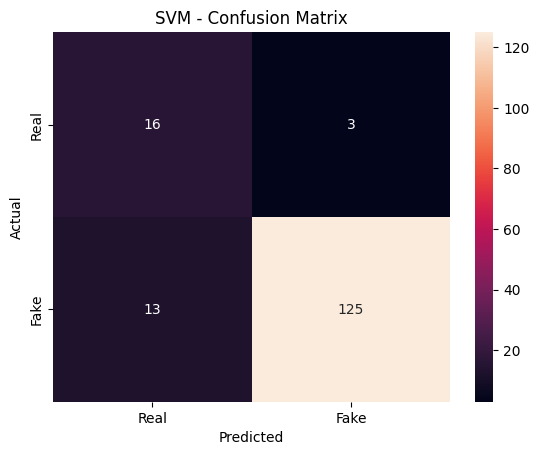

In [19]:

# SVM 
param_svm = {
    'C': [0.1, 0.5, 1],
    'kernel': ['linear', 'rbf'],
    'gamma': ['scale', 0.01, 0.1],
    
}
gs_svm = GridSearchCV(
    SVC(),
    param_svm,
    cv=5,
    scoring='f1'

)
gs_svm.fit(x_train_scaled, y_train_sm)
print("Best SVM Params:", gs_svm.best_params_)

best_svm = gs_svm.best_estimator_
evaluate_model("SVM", best_svm, x_train_scaled, y_train_sm, x_test_scaled, y_test)



Best DT Params: {'min_samples_split': 13, 'min_samples_leaf': 6, 'max_depth': 6, 'criterion': 'gini'}

 Decision Tree 
Train Accuracy : 0.9657
Test Accuracy  : 0.9172

Test Metrics 
Precision: 0.9699248120300752
Recall   : 0.9347826086956522
F1 Score : 0.9520295202952029

Confusion Matrix:
[[ 15   4]
 [  9 129]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.79      0.70        19
           1       0.97      0.93      0.95       138

    accuracy                           0.92       157
   macro avg       0.80      0.86      0.82       157
weighted avg       0.93      0.92      0.92       157



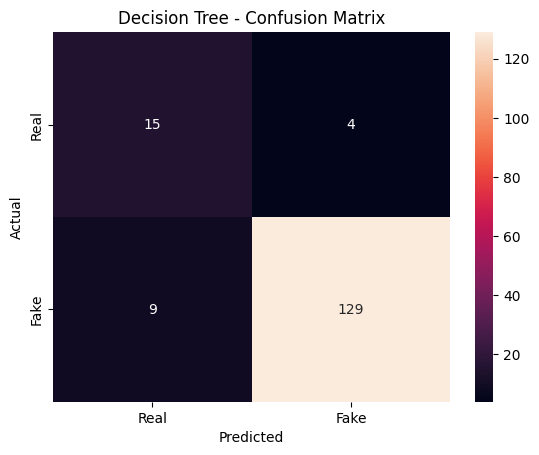

In [20]:
# decision trees
param_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [4,5, 6],               
    'min_samples_split': [12, 13, 15],     
    'min_samples_leaf': [6, 7, 8]   
    
}
rs_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dt,
    n_iter=5,
    cv=5,
    random_state=42,
    scoring='f1'
)

rs_dt.fit(x_train_sm, y_train_sm)

print("Best DT Params:", rs_dt.best_params_)

best_dt = rs_dt.best_estimator_
evaluate_model("Decision Tree", best_dt, x_train_sm, y_train_sm, x_test, y_test)


Best RF Params: {'n_estimators': 100, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_samples': 0.6, 'max_features': 'sqrt', 'max_depth': 8}

 Random Forest 
Train Accuracy : 0.9639
Test Accuracy  : 0.9172

Test Metrics 
Precision: 0.9699248120300752
Recall   : 0.9347826086956522
F1 Score : 0.9520295202952029

Confusion Matrix:
[[ 15   4]
 [  9 129]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.79      0.70        19
           1       0.97      0.93      0.95       138

    accuracy                           0.92       157
   macro avg       0.80      0.86      0.82       157
weighted avg       0.93      0.92      0.92       157



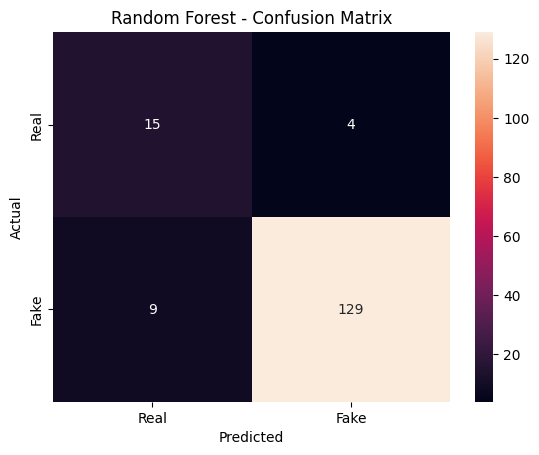

In [21]:

#  RANDOM FOREST 
param_rf = {
    'n_estimators': [100, 150, 200],
    'max_depth': [4, 6, 8],
    'min_samples_split': [15, 20, 25],
    'min_samples_leaf': [5, 7, 10],
    'max_features': ['sqrt', 'log2'],
    'max_samples': [0.6, 0.7],
    
}
rs_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_rf,
    n_iter=10,
    cv=5,
    random_state=42,
    scoring='f1'
)

rs_rf.fit(x_train_sm, y_train_sm)
print("Best RF Params:", rs_rf.best_params_)

best_rf = rs_rf.best_estimator_
evaluate_model("Random Forest", best_rf, x_train_sm, y_train_sm, x_test, y_test)
